<a href="https://colab.research.google.com/github/vikasverma9721/Machine-Learning-Models/blob/main/KNN_Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import necessary libraries...

In [ ]:
# libraries to help with raeding and manpulating data
import numpy as np
import pandas as pd

#Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To biuld model for prediction
from sklearn.neighbors import KNeighborsClassifier

# Library to split data
from sklearn.model_selection import train_test_split

#
from sklearn.preprocessing import StandardScaler

# To get deferent metrix scores
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# To ignore unncessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Loading the Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset/Breast Cancer Dataset.csv")

### Data Overview

#### View the first and last 5 rows of the dataset.

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


### Understand the shape of the dataset.

In [ ]:
df.shape

(569, 33)

- The dataset has 569 rows and 33 columns

### Check the data types of the columns for the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   id                       569 non-null    int64   
 1   diagnosis                569 non-null    category
 2   radius_mean              569 non-null    float64 
 3   texture_mean             569 non-null    float64 
 4   perimeter_mean           569 non-null    float64 
 5   area_mean                569 non-null    float64 
 6   smoothness_mean          569 non-null    float64 
 7   compactness_mean         569 non-null    float64 
 8   concavity_mean           569 non-null    float64 
 9   concave points_mean      569 non-null    float64 
 10  symmetry_mean            569 non-null    float64 
 11  fractal_dimension_mean   569 non-null    float64 
 12  radius_se                569 non-null    float64 
 13  texture_se               569 non-null    float64 
 14  perimeter_

### Check Total columns

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

### Change the datatype of the diagnosis column

In [ ]:
df['diagnosis'] = df['diagnosis'].astype('category')

In [ ]:
df.dtypes

,0
id,int64
diagnosis,category
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


### Statistical summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


### Check for duplicate values

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
564,False
565,False
566,False
567,False


- There are no duplicate values in the dataset.

### Check for missing values

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


- There are one column in missing value in the dataset.

### ***Remove unnecessary Columns***

In [ ]:
df1 = df.drop(columns = ['id','Unnamed: 32'], axis = 1)

In [ ]:
df1.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df1.tail()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [ ]:
df1.groupby(["diagnosis"]).count()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,357,357,357,357,357,357,357,357,357,357,...,357,357,357,357,357,357,357,357,357,357
M,212,212,212,212,212,212,212,212,212,212,...,212,212,212,212,212,212,212,212,212,212


In [ ]:
df1.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Exploratory Data Analysis (EDA)

### **Note**: In the case study, we will focus primarily on the model building aspects. We will only consider the key findings from the EDA. A detailed EDA is available in the Appendix section.

#### Univariate Analysis

In [ ]:
## Histplot & Boxplot
def histplot_boxplot_analysis(df1, column_name):

  df1[column_name].dtype in ['int64', 'float64']

  # Histplot & Boxplot setup
  fig, axes = plt.subplots(1,2, figsize = (14,5))
  sns.histplot(data = df1, x = column_name, kde = True, ax = axes[0], color = 'pink')
  axes[0].set_title(f"Distribution of {column_name}")

  sns.boxplot(data = df1, x = column_name, ax = axes[1], color = 'red')
  axes[1].set_title(f"Boxplot of {column_name}")
  plt.tight_layout()
  plt.show()



## function to create Labeled Barplot
def labeled_barplot(df1, column_name):
  plt.figure(figsize = (5,5))
  ax = sns.countplot(data = df1, x = column_name, palette = "Set2")

  total = len(df1[column_name])
  for x in ax.patches:
    percentage = f"{100 * x.get_height() / total:.1f}%"
    x_pos = x.get_x() + x.get_width() / 2
    y_pos = x.get_height()
    ax.annotate(percentage, (x_pos, y_pos), ha = 'center', va = 'bottom', fontsize = 10, fontweight = "bold")
  plt.show()

### ***Observations on Diagnosis***

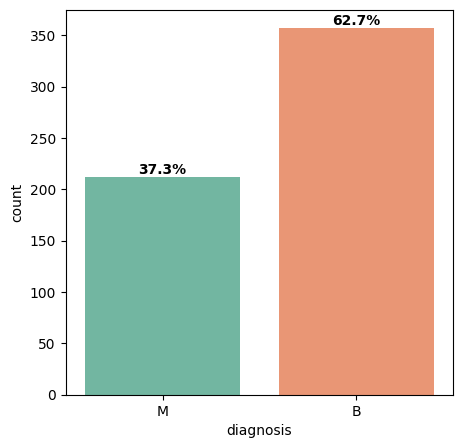

In [ ]:
labeled_barplot(df1,"diagnosis")

### ***Observations of radius_mean***

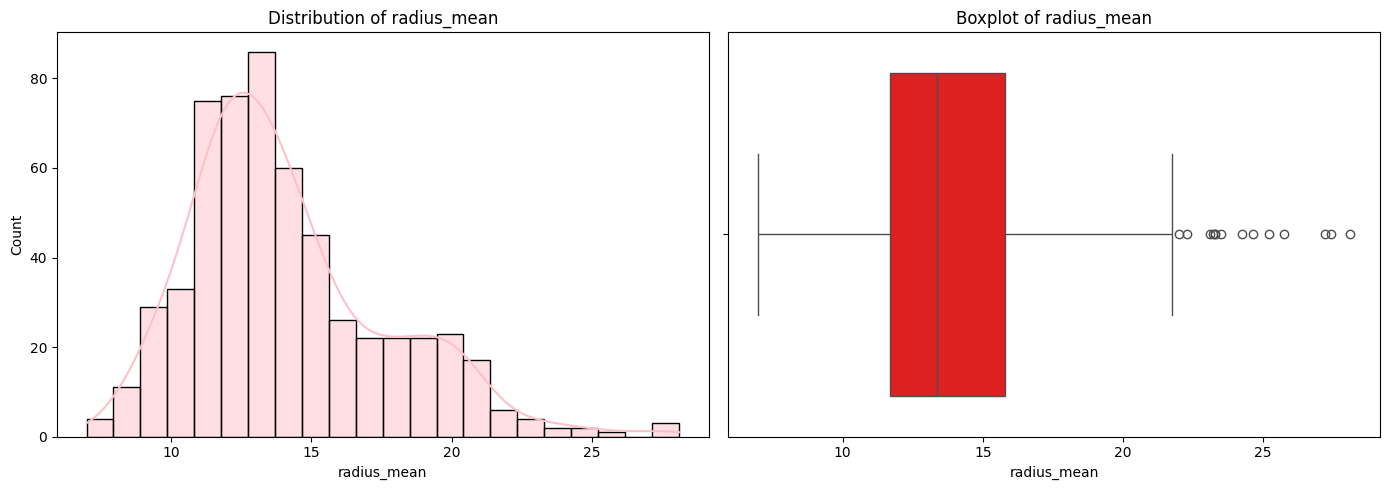

In [ ]:
histplot_boxplot_analysis(df1, 'radius_mean')

### ***Observations of texture_mean***

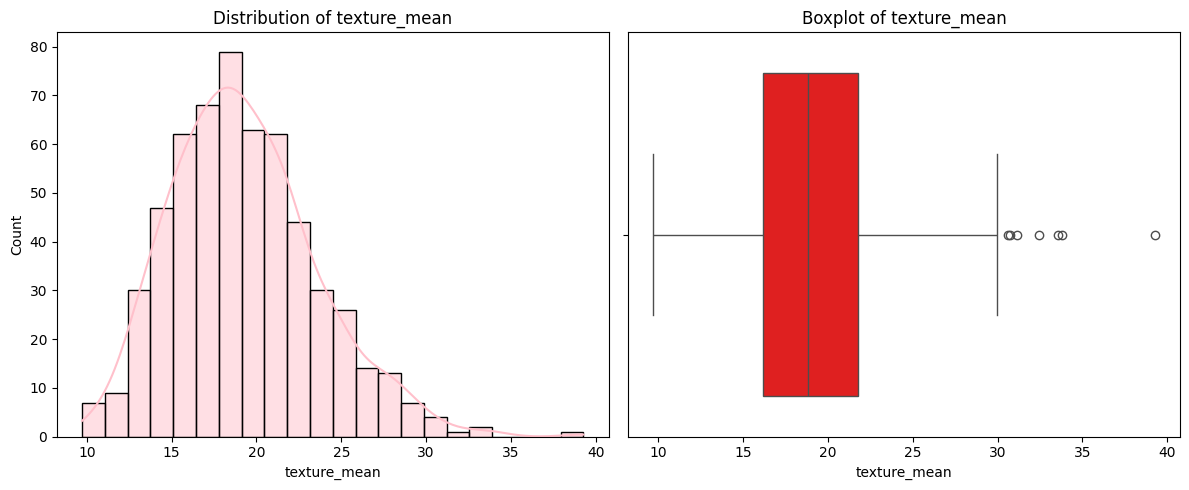

In [ ]:
histplot_boxplot_analysis(df1, "texture_mean")

### ***Observations on perimeter_mean***

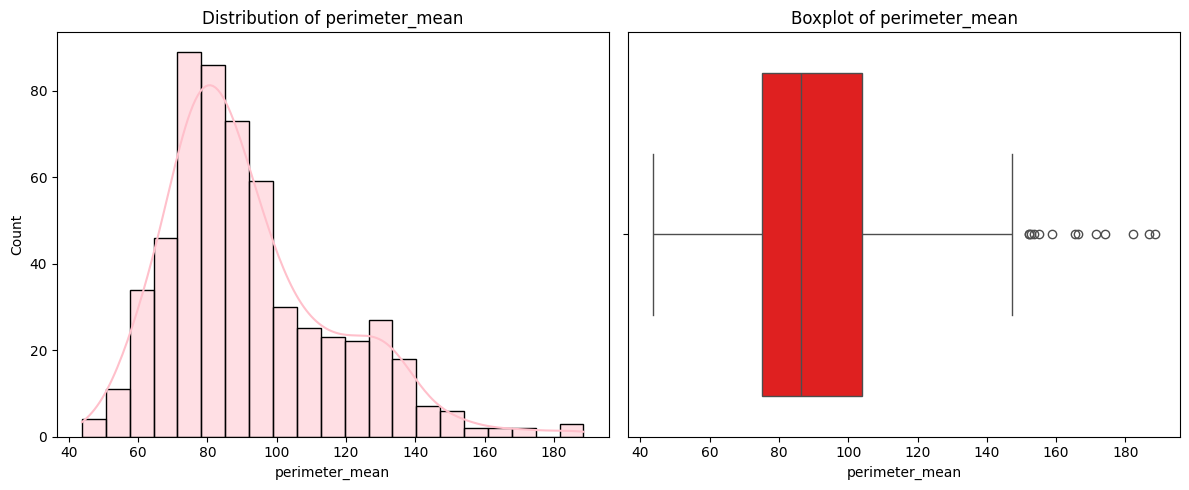

In [ ]:
histplot_boxplot_analysis(df1, "perimeter_mean")

### ***Observations on area_mean***

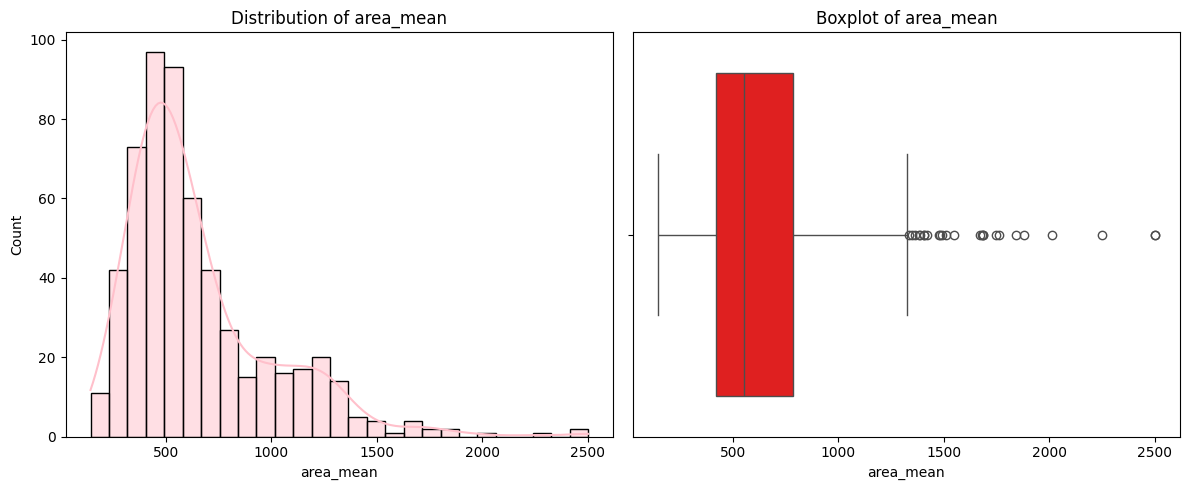

In [ ]:
histplot_boxplot_analysis(df1, "area_mean")

### ***Observations on smoothness_mean***

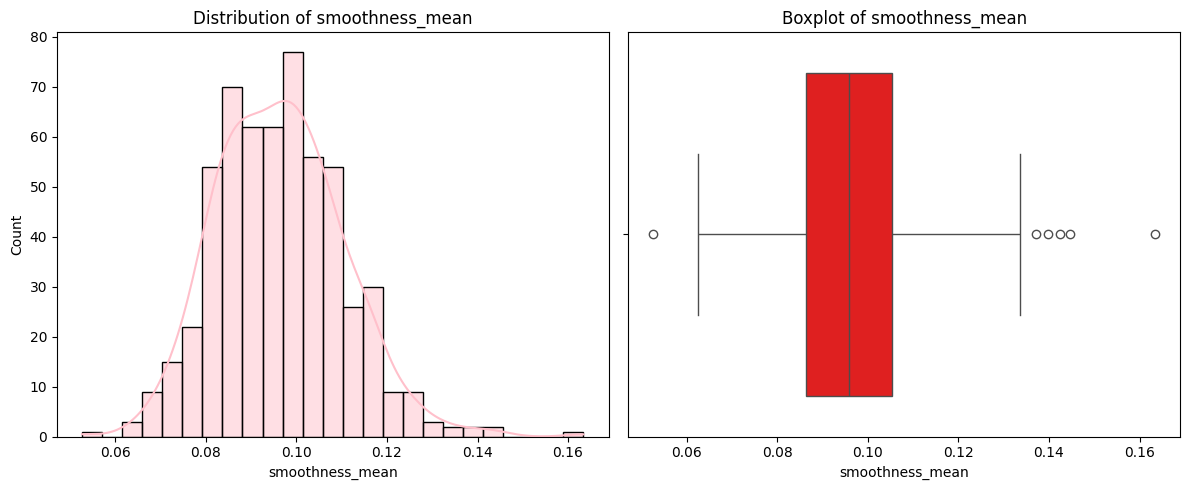

In [ ]:
histplot_boxplot_analysis(df1, "smoothness_mean")

### ***Observations on compactness_mean***

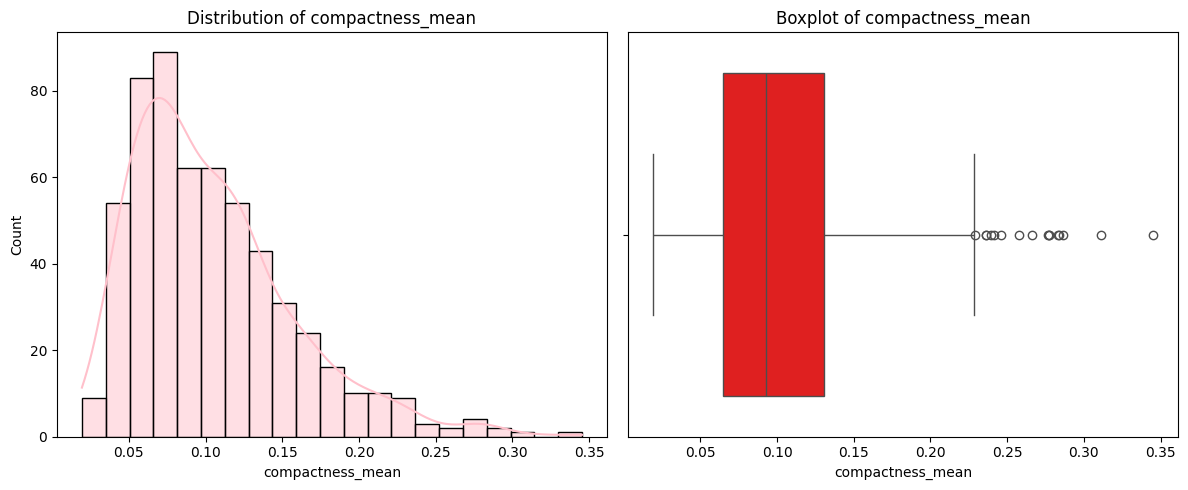

In [ ]:
histplot_boxplot_analysis(df1, "compactness_mean")

### ***Observations on concavity_mean***

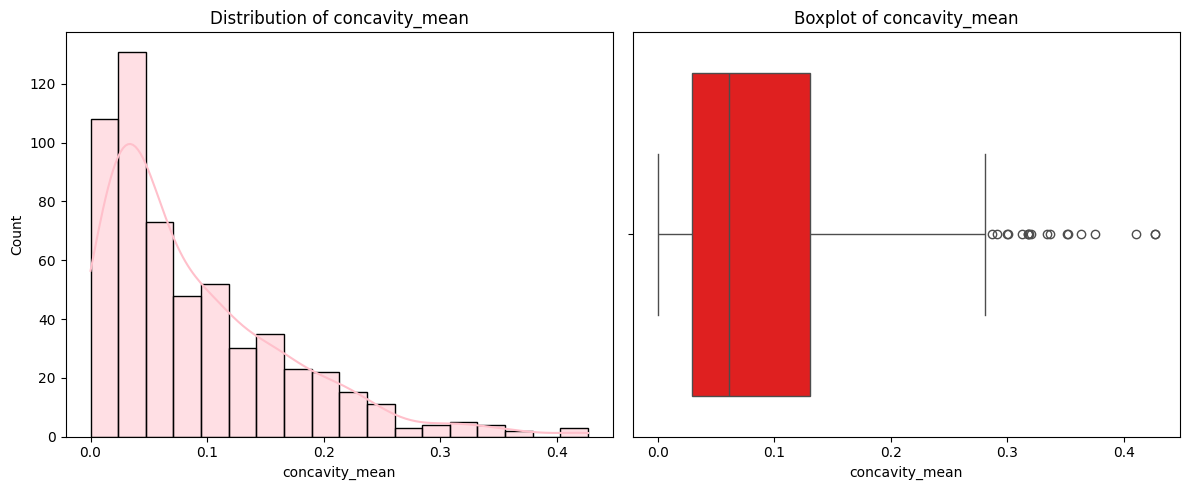

In [ ]:
histplot_boxplot_analysis(df1, "concavity_mean")

### ***Observations on concave points_mean***

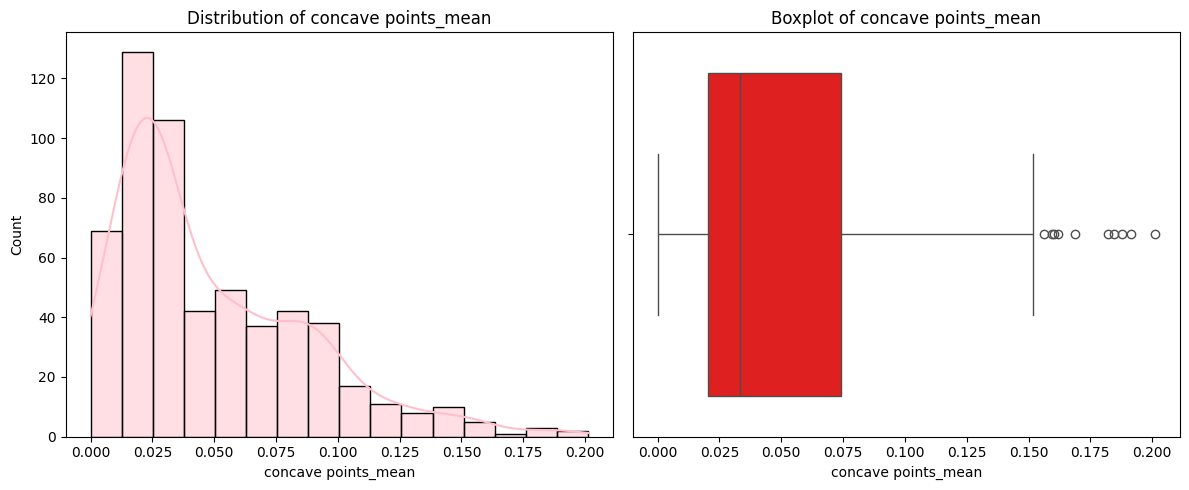

In [ ]:
histplot_boxplot_analysis(df1, "concave points_mean")

### ***Observations on symmetry_mean***

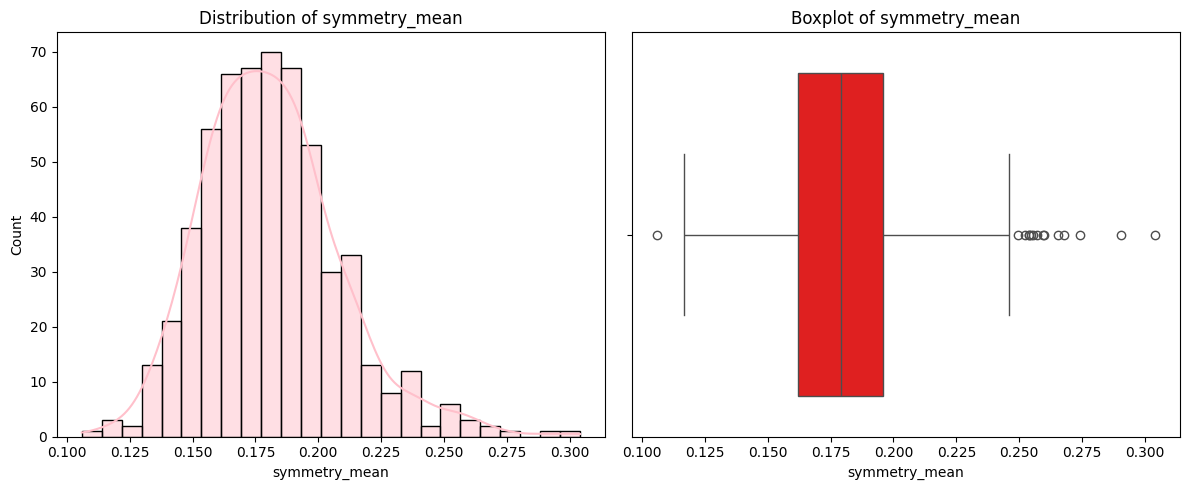

In [ ]:
histplot_boxplot_analysis(df1, "symmetry_mean")

### ***Observations on fractal_dimension_mean***

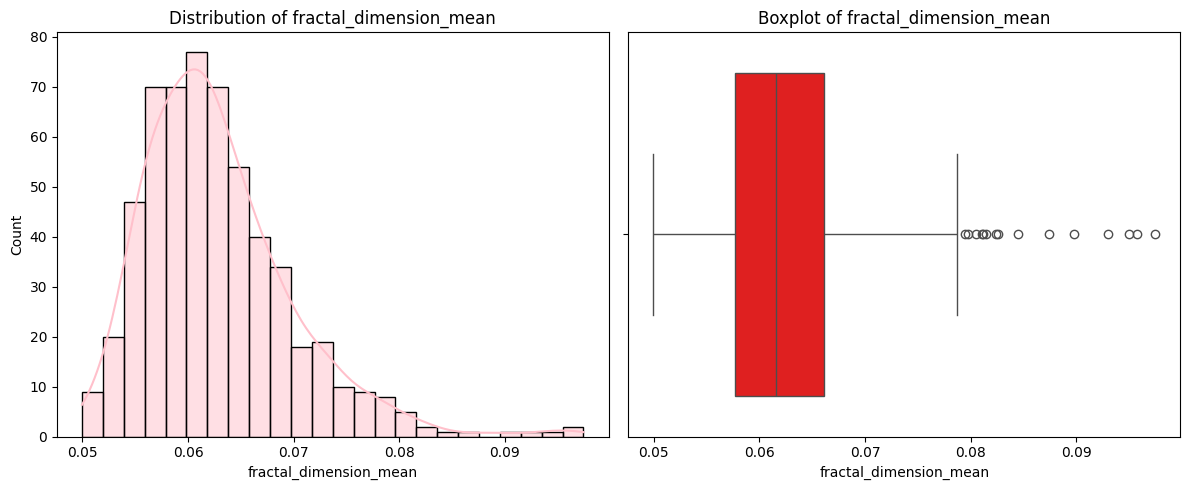

In [ ]:
histplot_boxplot_analysis(df1, "fractal_dimension_mean")

### ***Observations on radius_se***

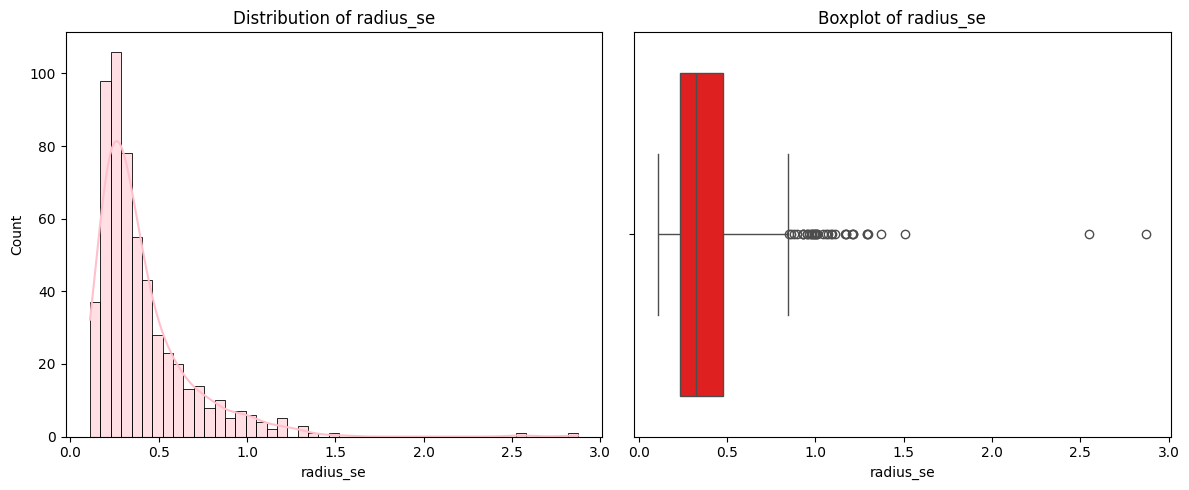

In [ ]:
histplot_boxplot_analysis(df1, "radius_se")

### ***Observations on texture_se***

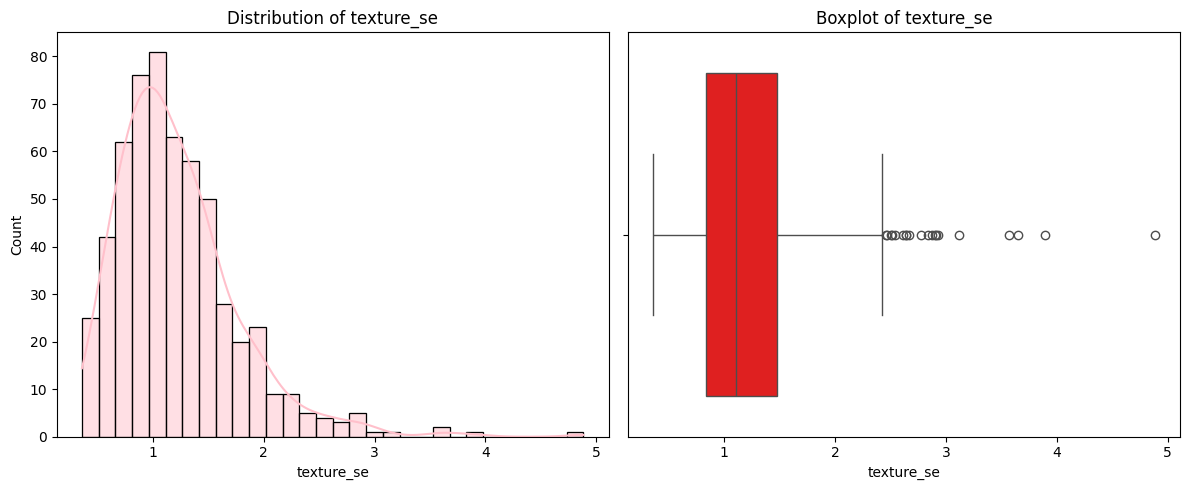

In [ ]:
histplot_boxplot_analysis(df1, "texture_se")

### ***Observations on perimeter_se***

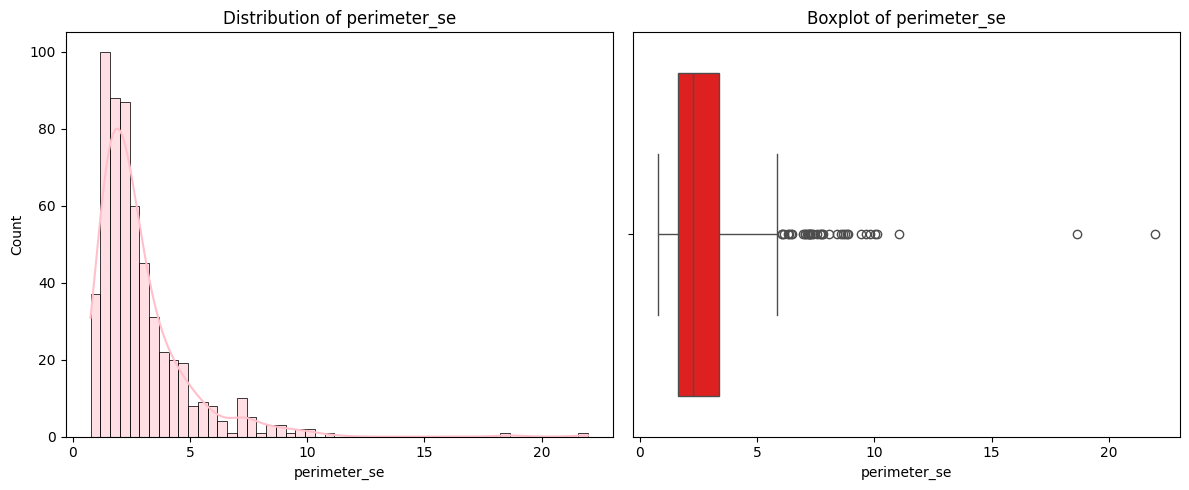

In [ ]:
histplot_boxplot_analysis(df1, "perimeter_se")

### ***Observations on area_se***

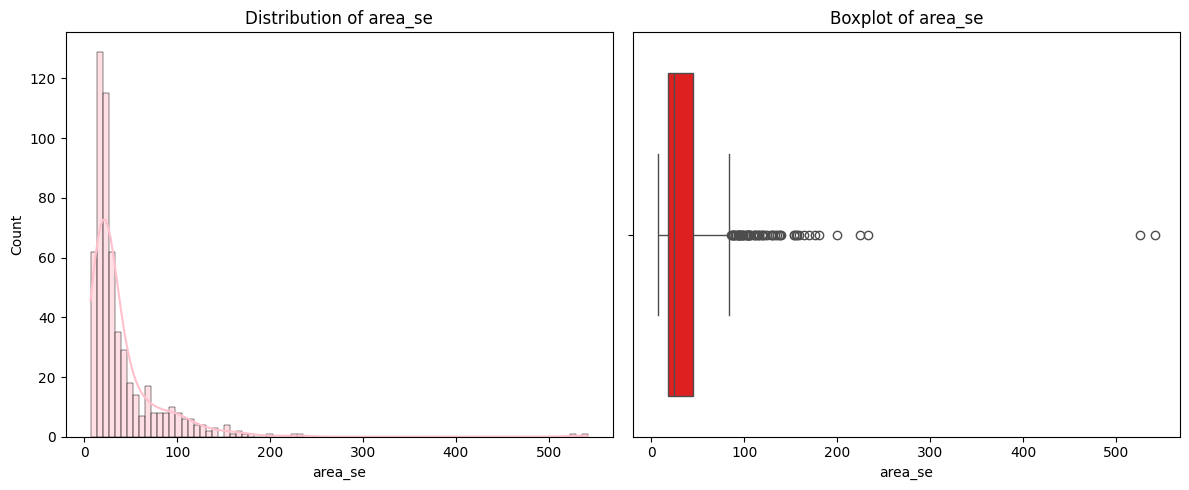

In [ ]:
histplot_boxplot_analysis(df1, "area_se")

### ***Observations on smoothness_se***

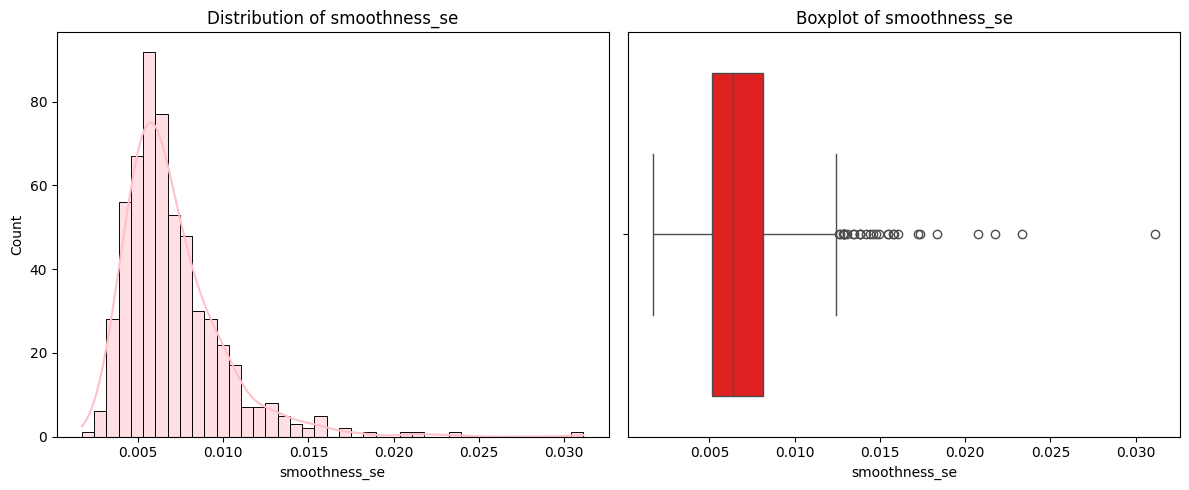

In [ ]:
histplot_boxplot_analysis(df1, "smoothness_se")

### ***Observations on compactness_se***

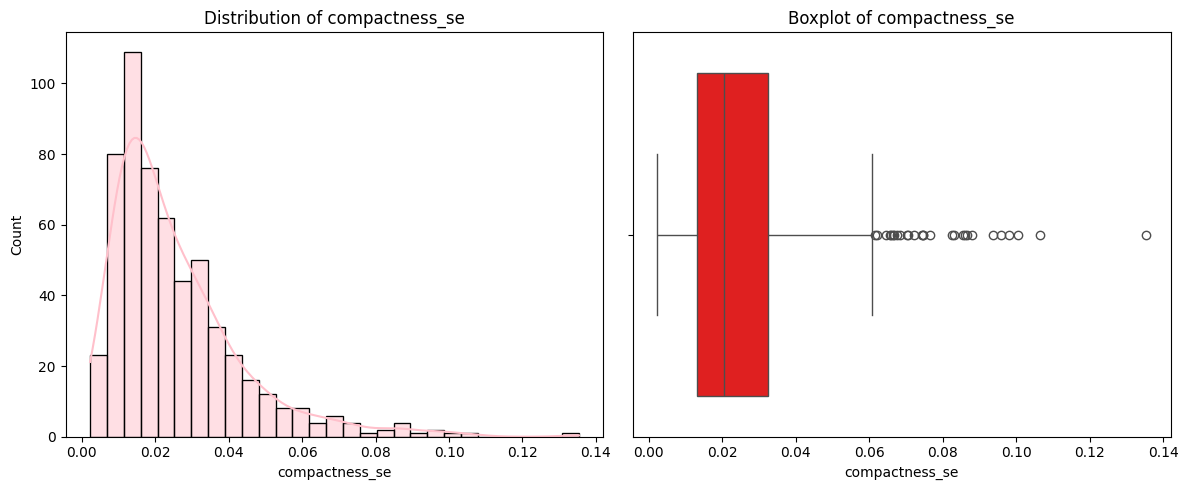

In [ ]:
histplot_boxplot_analysis(df1, "compactness_se")

### ***Observations on concavity_se***

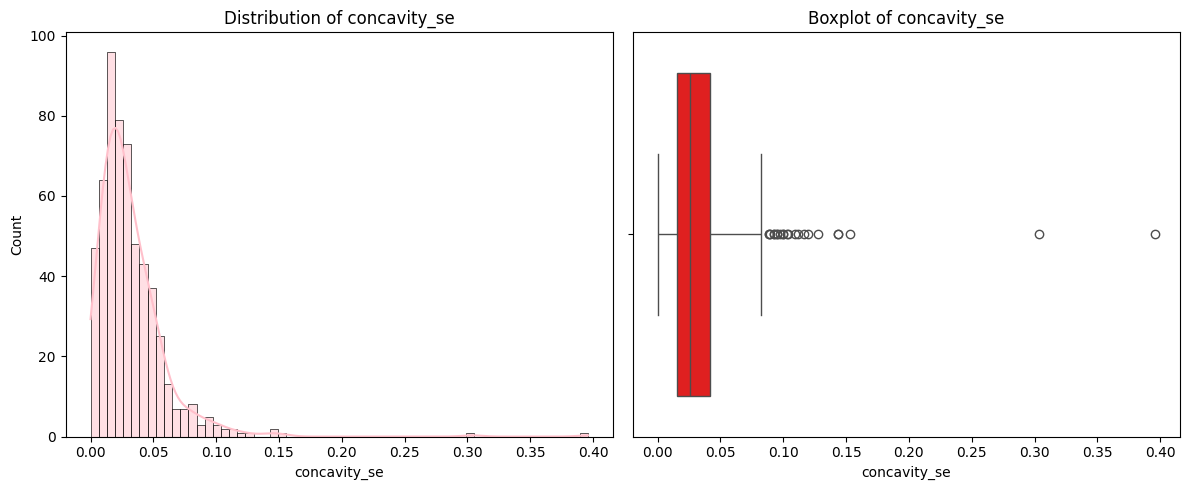

In [ ]:
histplot_boxplot_analysis(df1, "concavity_se")

### ***Observations on concave points_se***

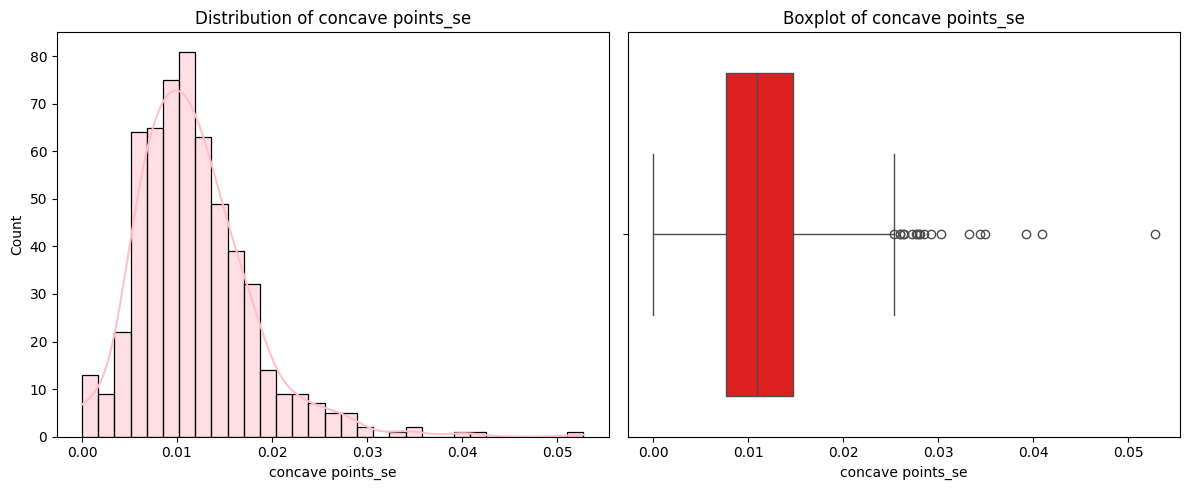

In [ ]:
histplot_boxplot_analysis(df1, "concave points_se")

### ***Observation on symmetry_se***

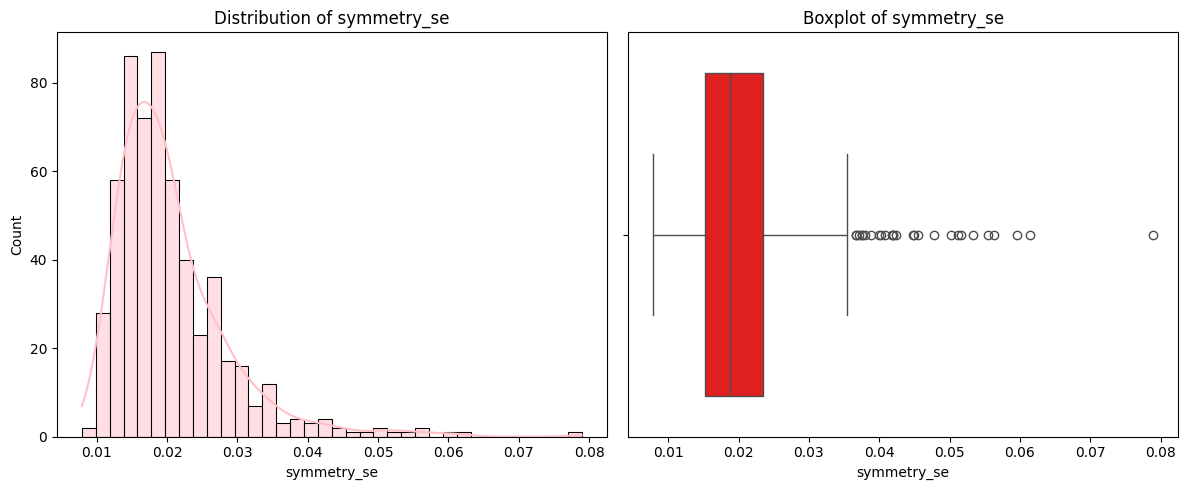

In [ ]:
histplot_boxplot_analysis(df1, "symmetry_se")

### ***Observations on fractal_dimension_se***

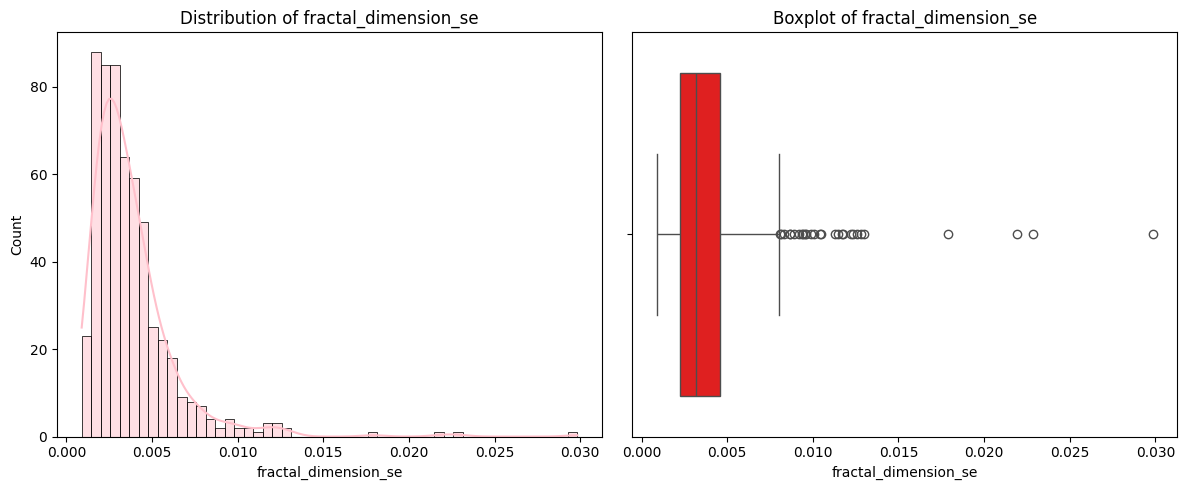

In [ ]:
histplot_boxplot_analysis(df1, "fractal_dimension_se")

### ***Observations on radius_worst***

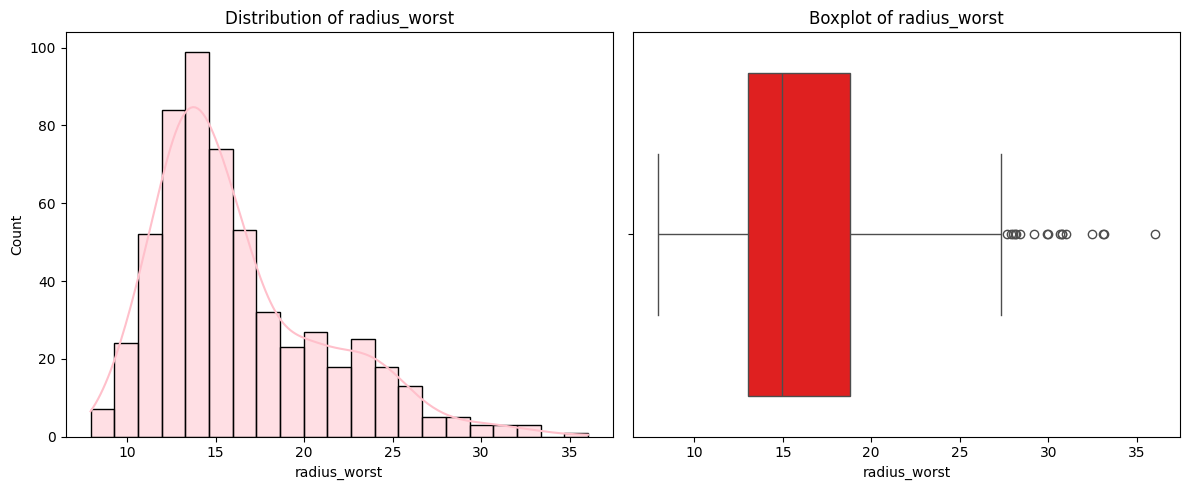

In [ ]:
histplot_boxplot_analysis(df1, "radius_worst")

### ***Observations on texture_worst***

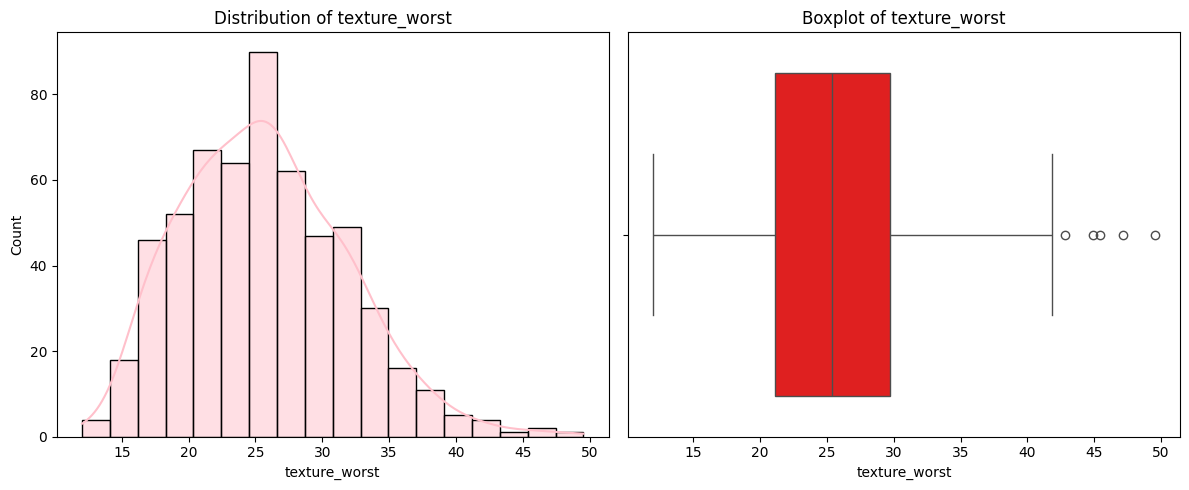

In [ ]:
histplot_boxplot_analysis(df1, "texture_worst")

### ***Observations on perimeter_worst***

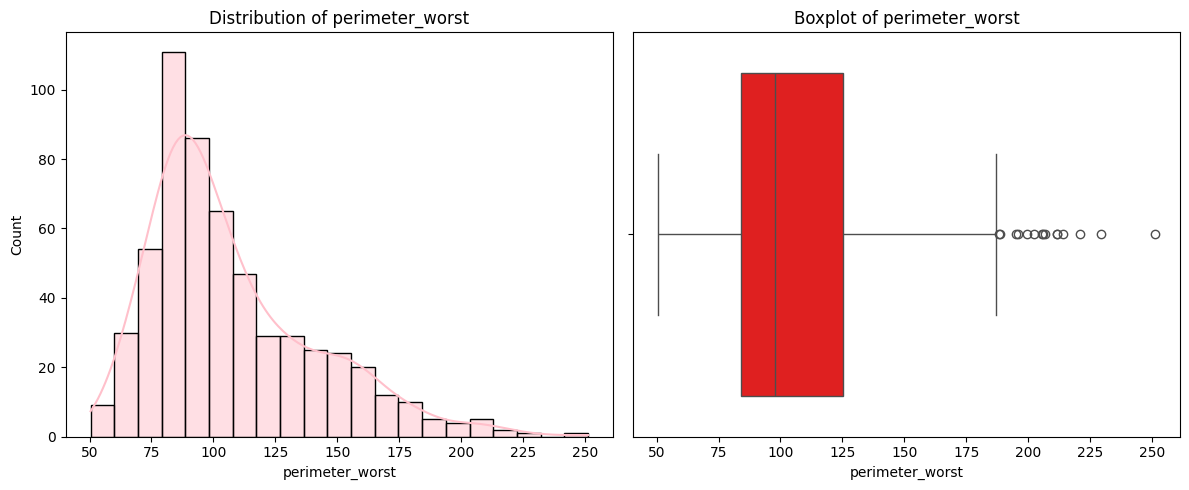

In [ ]:
histplot_boxplot_analysis(df1, "perimeter_worst")

### ***Observations on area_worst***

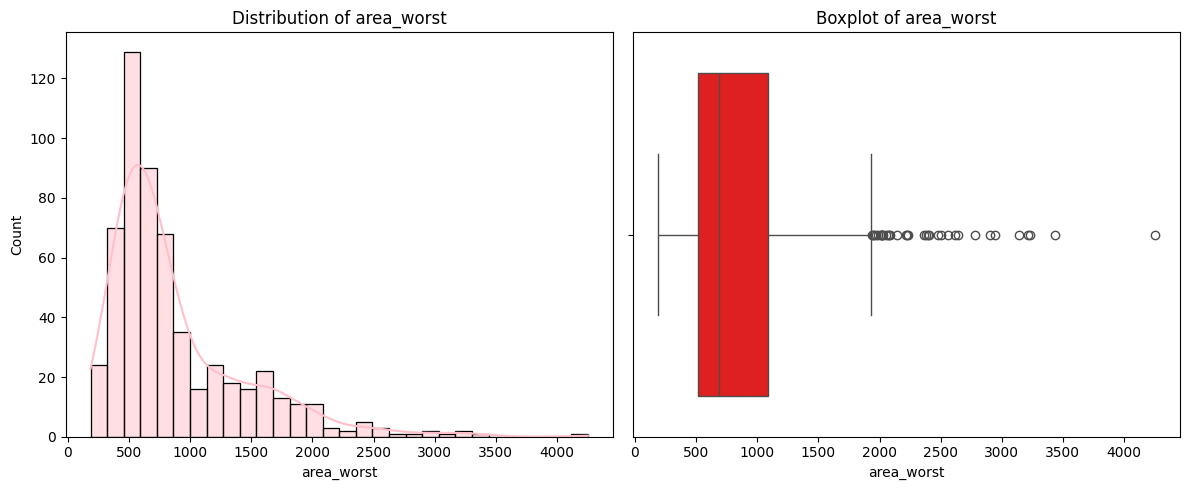

In [ ]:
histplot_boxplot_analysis(df1, "area_worst")

### ***Observations on smoothness_worst***

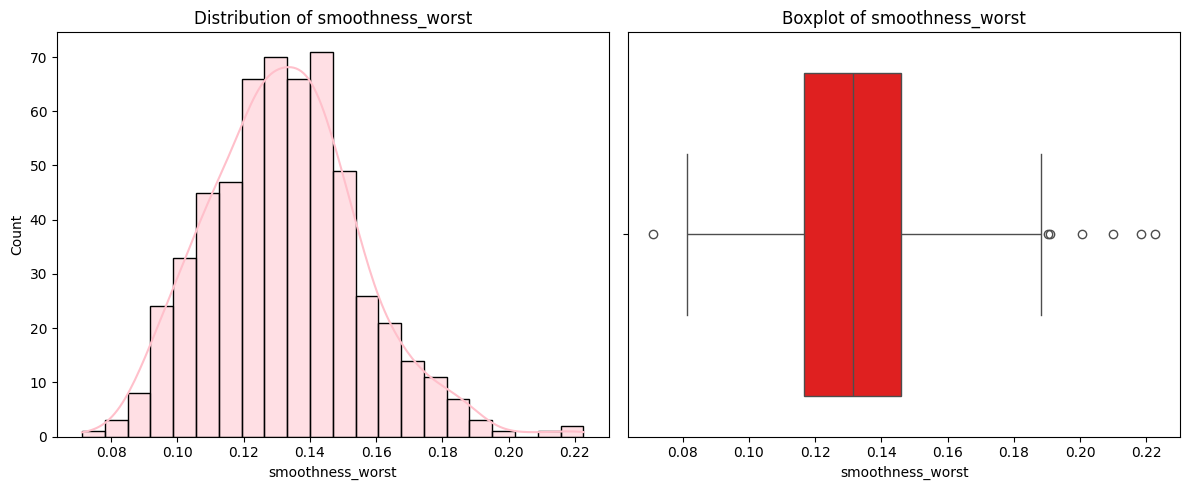

In [ ]:
histplot_boxplot_analysis(df1, "smoothness_worst")

### ***Observations on compactness_worst***

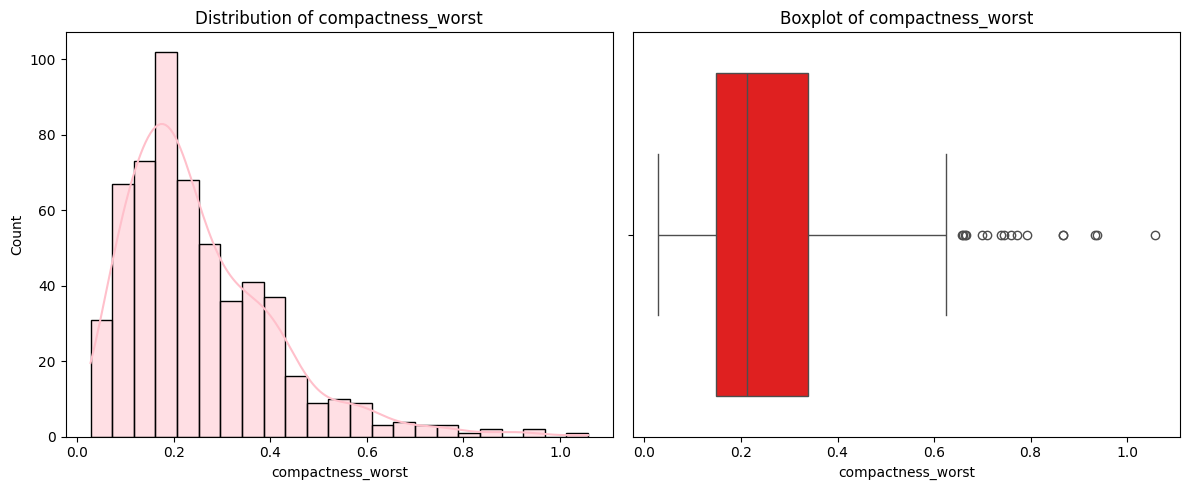

In [ ]:
histplot_boxplot_analysis(df1, "compactness_worst")

### ***Observations on concavity_worst***

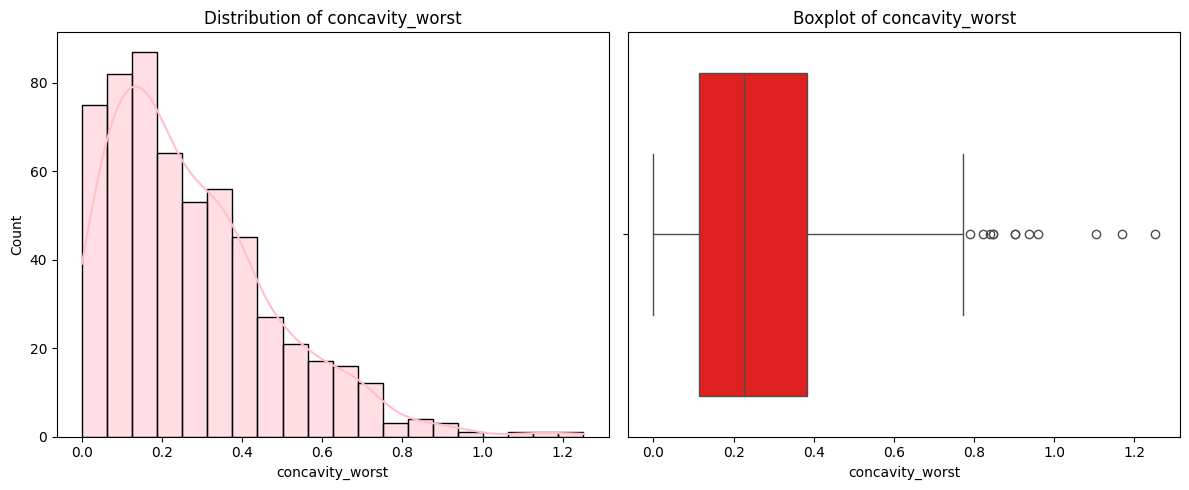

In [ ]:
histplot_boxplot_analysis(df1, "concavity_worst")

### ***Observations on concave points_worst***

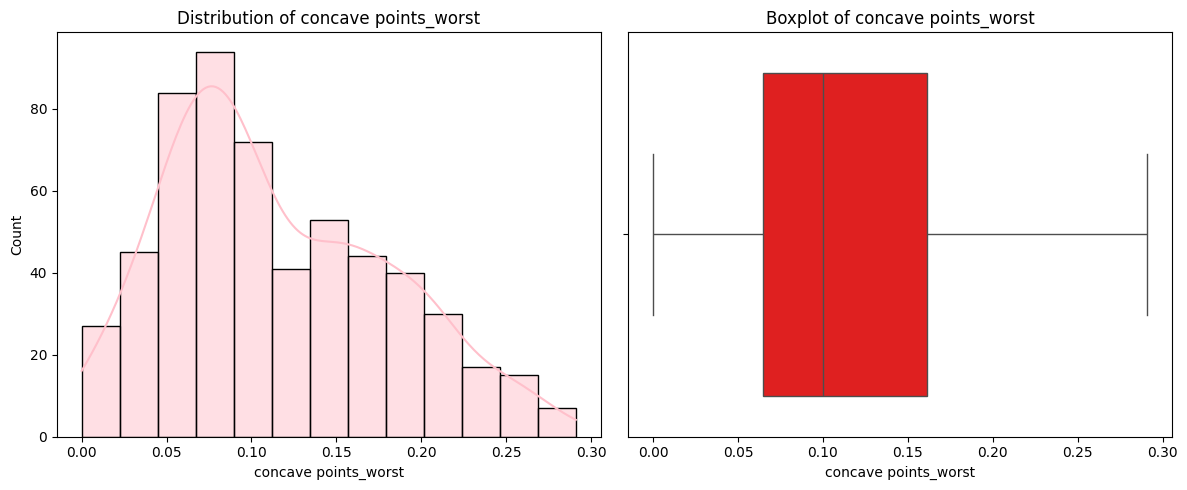

In [ ]:
histplot_boxplot_analysis(df1, "concave points_worst")

### ***Observations on symmetry_worst***

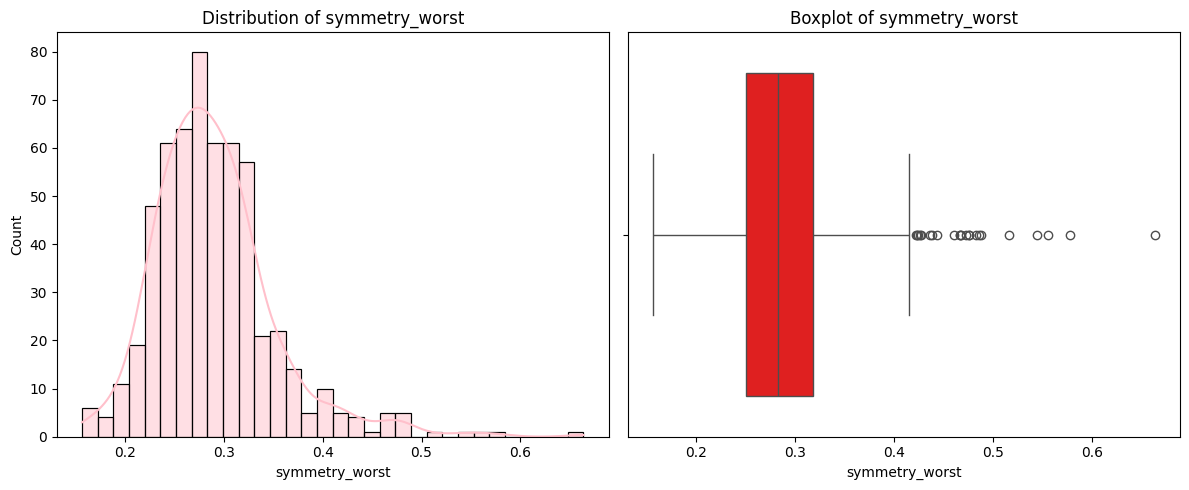

In [ ]:
histplot_boxplot_analysis(df1, "symmetry_worst")

### ***Observations on fractal_dimension_worst***

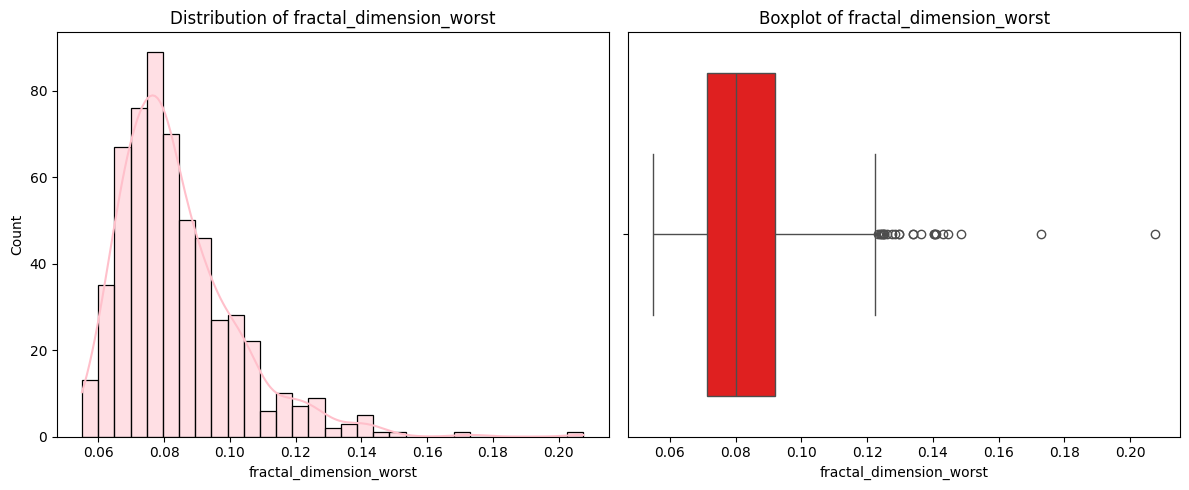

In [ ]:
histplot_boxplot_analysis(df1, "fractal_dimension_worst")

### ***Bivariate Analysis***

In [ ]:
def correlation_heatmap(df1):
  numerical_columns = df1.select_dtypes(include = [np.number])
  corr_matrix = numerical_columns.corr()

  plt.figure(figsize = (20,16))
  sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f", linewidth = 0.5)
  plt.title("Correlation Heatmap Of All Numerical Features", fontsize = 16, fontweight = "bold")
  plt.tight_layout()
  plt.show()


## pairplot
def correlation_pairplot(dataframe, target_column):

    selected_features = [
        'radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean'
    ]


    plt.figure(figsize=(15, 12))
    grid = sns.pairplot(
        dataframe,
        vars=selected_features,
        hue=target_column,
        palette='Set1',
        diag_kind='kde',
        plot_kws={'alpha': 0.6, 's': 30}
    )

    grid.fig.suptitle(f'Pairplot Matrix for Key Features (Separated by {target_column})', y=1.02, fontsize=14, fontweight='bold')

    plt.show()

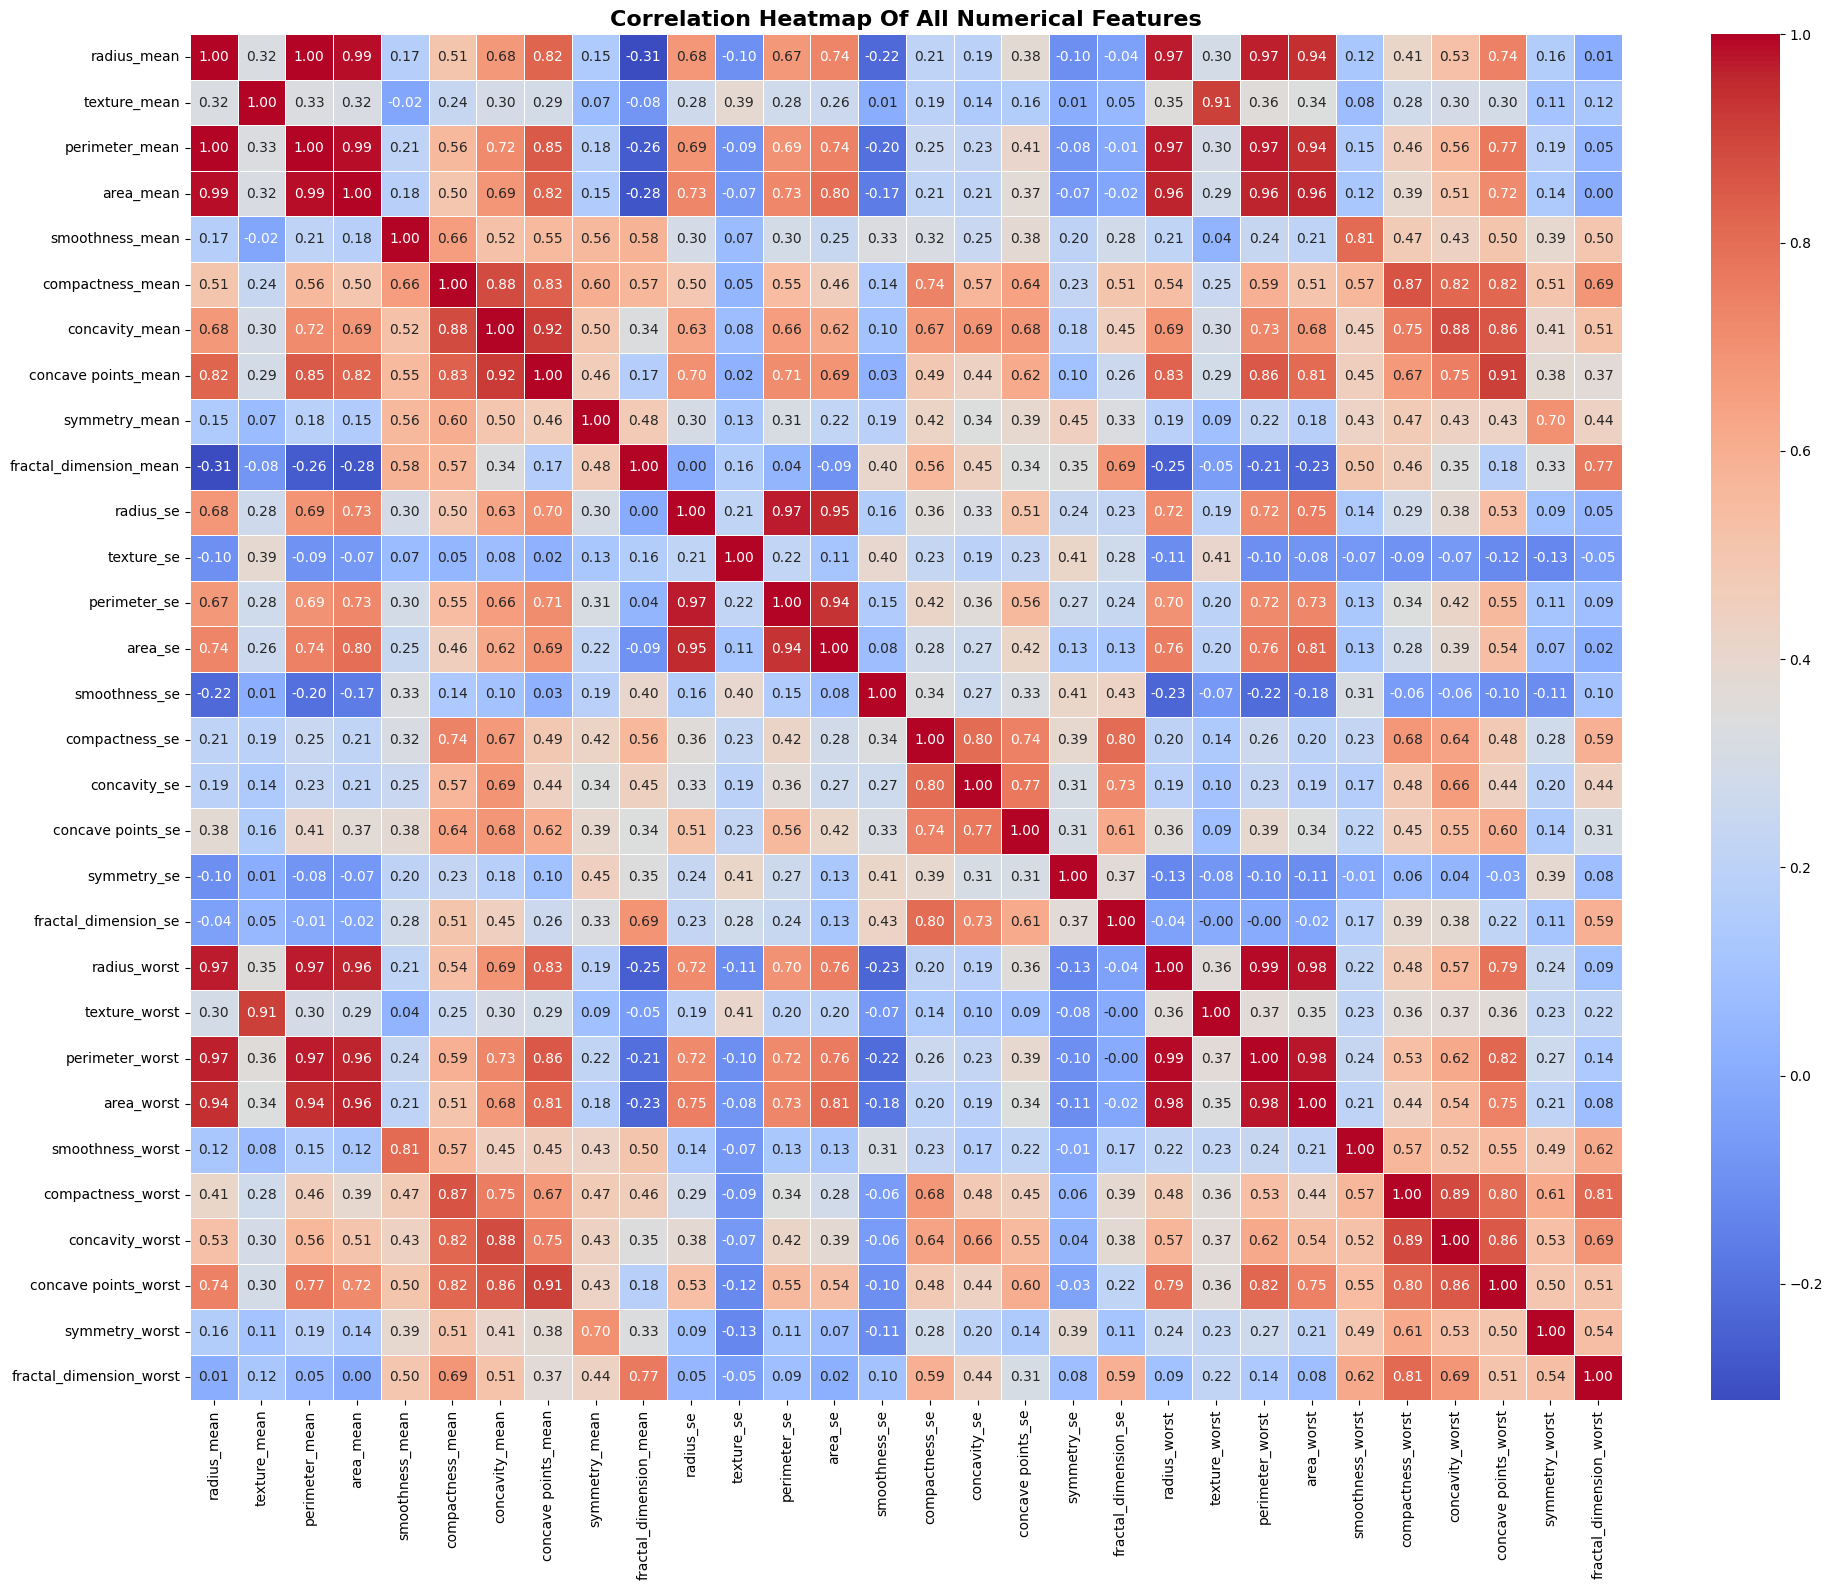

In [ ]:
correlation_heatmap(df1)

<Figure size 1500x1200 with 0 Axes>

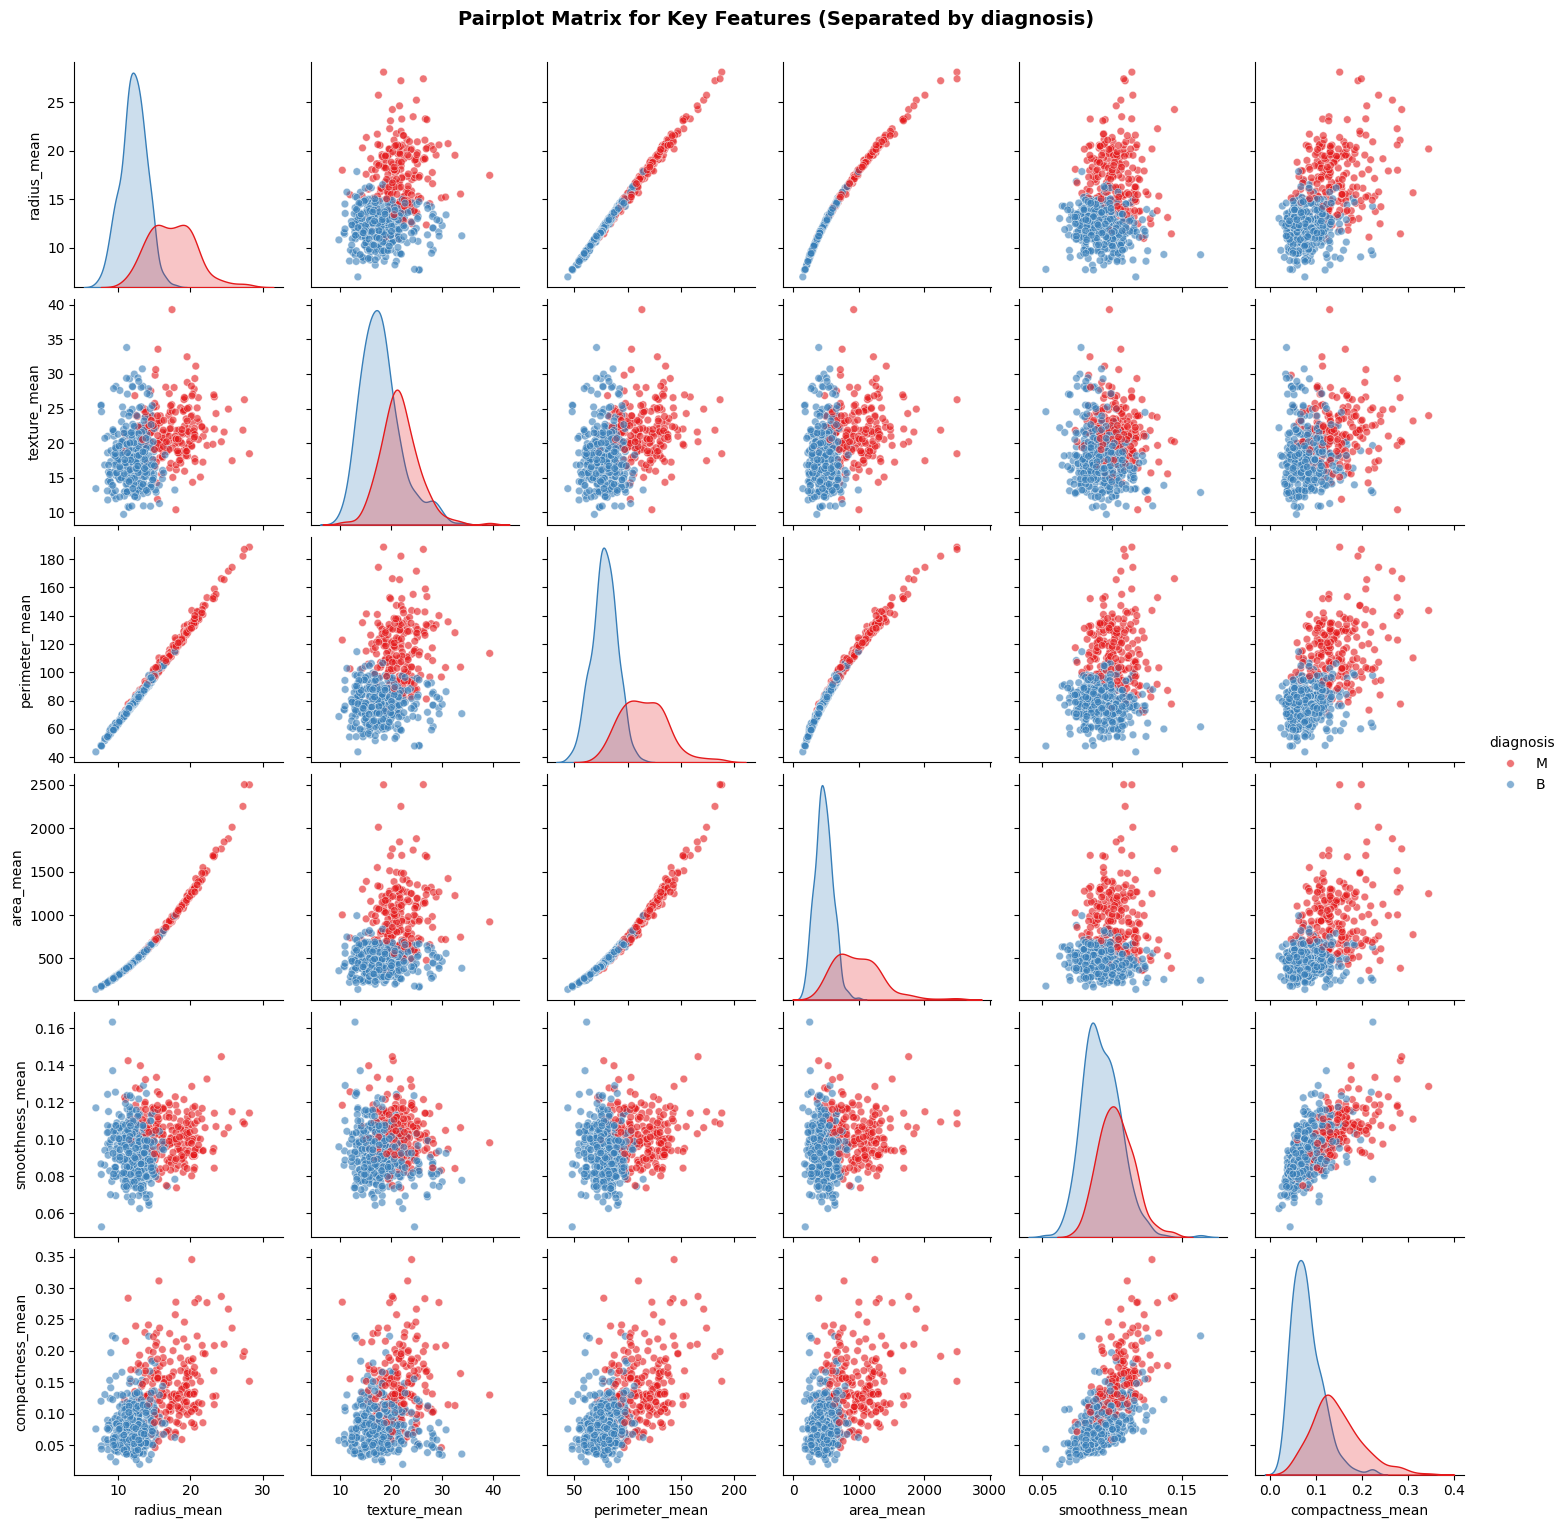

In [ ]:
correlation_pairplot(df1, 'diagnosis')

#### ***Converting Target Column to Numerical Type***

In [ ]:
df1['diagnosis'] = df1['diagnosis'].map({'M': 1, 'B': 0})
df1['diagnosis'] = df1['diagnosis'].astype('int64')
print(df1['diagnosis'].head())

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


In [ ]:
df1.dtypes

,0
diagnosis,int64
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64


#### Separating Features (X) and Target (y)

In [ ]:
X = df1.drop(columns = ['diagnosis'], axis = 1)
Y = df1['diagnosis']

In [ ]:
X.shape
Y.shape
print(f"X Shape = ",X.shape)
print(f"Y Shape = ",Y.shape)

X Shape =  (569, 30)
Y Shape =  (569,)


In [ ]:
X_train,X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.30, random_state = 42)

#### Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X.columns)

####

### X Train Scaled Statistical summary

In [ ]:
X_train_scaled_df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,...,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02,3.980000e+02
mean,2.677925e-16,-5.534378e-16,-6.181543e-16,2.075392e-16,8.926416e-18,-9.595897e-17,-2.097708e-16,-1.350120e-16,7.252713e-16,2.800663e-16,...,5.958383e-16,-1.986128e-16,-3.012665e-16,-1.651387e-16,9.104945e-16,-1.740651e-16,1.294330e-16,8.703256e-17,-2.733715e-16,1.428227e-16
std,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,...,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00,1.001259e+00
min,-1.836464e+00,-2.245111e+00,-1.810311e+00,-1.365377e+00,-2.433051e+00,-1.640911e+00,-1.132915e+00,-1.286097e+00,-2.370161e+00,-1.754890e+00,...,-1.587373e+00,-2.243853e+00,-1.600220e+00,-1.154748e+00,-2.197162e+00,-1.446868e+00,-1.370635e+00,-1.784161e+00,-2.117613e+00,-1.628809e+00
25%,-6.863161e-01,-7.102232e-01,-6.781539e-01,-6.517481e-01,-7.572809e-01,-7.800619e-01,-7.523426e-01,-7.367012e-01,-6.980367e-01,-6.905392e-01,...,-6.701191e-01,-7.380288e-01,-6.906849e-01,-6.320618e-01,-7.587574e-01,-6.855591e-01,-7.760495e-01,-7.829110e-01,-6.511070e-01,-7.077340e-01
50%,-2.551700e-01,-1.090984e-01,-2.587218e-01,-3.167308e-01,-9.722838e-02,-2.350839e-01,-3.369099e-01,-3.804602e-01,-5.620170e-02,-1.849553e-01,...,-2.737620e-01,-5.832825e-02,-2.911130e-01,-3.407646e-01,-2.705181e-02,-2.683733e-01,-2.159212e-01,-2.283327e-01,-1.213010e-01,-1.927549e-01
75%,5.419902e-01,5.692460e-01,5.510809e-01,3.839945e-01,6.191923e-01,5.332330e-01,5.017380e-01,6.776427e-01,5.679340e-01,4.618745e-01,...,5.048709e-01,6.496585e-01,5.428353e-01,3.147198e-01,6.187627e-01,6.232624e-01,5.931956e-01,7.297391e-01,4.394337e-01,4.691161e-01
max,3.945850e+00,4.780684e+00,3.967339e+00,5.137153e+00,4.904988e+00,4.068820e+00,4.357306e+00,4.055859e+00,4.608979e+00,4.803888e+00,...,4.120586e+00,3.999076e+00,4.353182e+00,5.915678e+00,3.767380e+00,4.640507e+00,3.241075e+00,2.535233e+00,6.033124e+00,5.113359e+00


### Hyperparameter Tuning

In [ ]:
Knn = KNeighborsClassifier(n_neighbors= 5)

### Fit the model

In [ ]:
Knn.fit(X_train_scaled, Y_train)

KNeighborsClassifier()

### Making Predictions on Unseen Test Data

In [ ]:
y_pred = Knn.predict(X_test_scaled)

### Visualizing Confusion Matrix

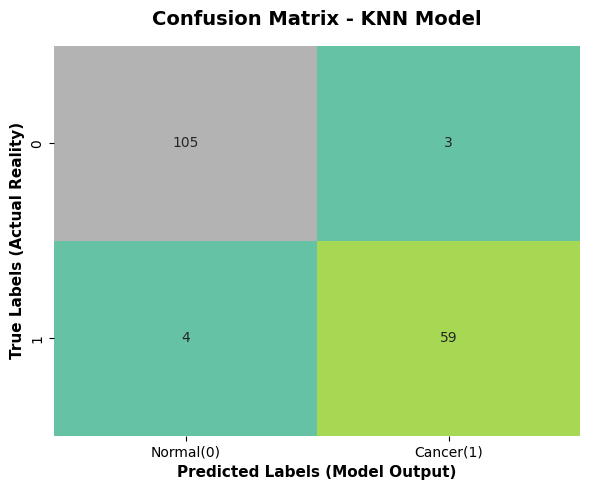

In [ ]:
confusion_mtx = confusion_matrix(Y_test, y_pred)
plt.figure(figsize = (6,5))
sns.heatmap(confusion_mtx, annot = True, fmt = "d", cmap = "Set2", cbar = False, xticklabels = ["Normal(0)", "Cancer(1)"])
plt.title("Confusion Matrix - KNN Model", fontsize = 14, fontweight = "bold", pad = 15)
plt.xlabel("Predicted Labels (Model Output)", fontsize = 11, fontweight = "bold")
plt.ylabel("True Labels (Actual Reality)", fontsize = 11, fontweight = "bold")
plt.tight_layout()
plt.show()

### Classification Report

In [ ]:

print(classification_report(Y_test, y_pred, target_names=["Normal (0)", "Cancer (1)"]))

              precision    recall  f1-score   support

  Normal (0)       0.96      0.97      0.97       108
  Cancer (1)       0.95      0.94      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



#### PREDICTION BY ENTERING A ROW NUMBER

In [ ]:
row_num = int(input(f"Enter Test Row Number (0 to {len(X_test) - 1}) = "))
if 0 <= row_num < len(X_test):
  raw_feature = X_test.iloc[row_num].values.reshape(1, -1)
  actual_label = Y_test.iloc[row_num]
  scaled_feature = scaler.transform(raw_feature)
  row_prediction = Knn.predict(scaled_feature)
  print(f"DIAGNOSIS REPORT FOR TEST ROW NUMBER = {row_num}")
  status_map = {0 : "Normal / Benign", 1 : "Cancer / Malignant"}
  print(f"Model Prediction = {status_map[row_prediction[0]]} ({row_prediction[0]})")
  print(f"Actual Prediction = {status_map[actual_label]} ({actual_label})")
else:
  print("Invalid Row Number")

Enter Test Row Number (0 to 170) = 8
DIAGNOSIS REPORT FOR TEST ROW NUMBER = 8
Model Prediction = Cancer / Malignant (1)
Actual Prediction = Normal / Benign (0)


#### Model's incorrect prediction row number

In [ ]:
count = 0
for i in range(len(Y_test)):
  actual = Y_test.iloc[i]
  predicted = y_pred[i]
  if  actual == 0 and predicted == 1:
    print(f"Found Mistake at Test Row Number = {i}")
    count += 1

print(f"\nTotal such mistake found = {count}")

Found Mistake at Test Row Number = 8
Found Mistake at Test Row Number = 52
Found Mistake at Test Row Number = 91

Total such mistake found = 3


In [ ]:
count = 0
for i in range(len(Y_test)):
    actual = Y_test.iloc[i]
    predicted = y_pred[i]
    if actual == 1 and predicted == 0:
        print(f"Found Mistake at Test Row Number: {i}")
        count += 1

print(f"\nTotal such dangerous mistakes found: {count}")

Found Mistake at Test Row Number: 13
Found Mistake at Test Row Number: 20
Found Mistake at Test Row Number: 77
Found Mistake at Test Row Number: 164

Total such dangerous mistakes found: 4
